# WoFS Rollout Visualization

This notebook visualizes:
- Rollout metrics CSV: `/tmp/credit_wofs_rollout_example/rollout_metrics.csv`
- Rollout forecast outputs directory: `/tmp/credit_wofs_rollout_example/wofs_20190703_0000_mem01`
  - Supports either a Zarr store or a directory of NetCDF (`*.nc`) forecast files.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

In [2]:
metrics_path = Path('/tmp/credit_wofs_rollout_example/rollout_metrics.csv')
rollout_path = Path('/tmp/credit_wofs_rollout_example/wofs_20190703_0000_mem01')

print('Metrics path exists :', metrics_path.exists(), metrics_path)
print('Rollout path exists :', rollout_path.exists(), rollout_path)
if rollout_path.exists() and rollout_path.is_dir():
    nc_files = sorted(rollout_path.glob('*.nc'))
    print(f'NetCDF files found  : {len(nc_files)}')

Metrics path exists : True /tmp/credit_wofs_rollout_example/rollout_metrics.csv
Rollout path exists : True /tmp/credit_wofs_rollout_example/wofs_20190703_0000_mem01
NetCDF files found  : 36


## 1) Rollout metrics CSV

In [3]:
df = pd.read_csv(metrics_path)
print('Shape:', df.shape)
display(df.head())

id_cols = [c for c in ['case', 'forecast_hour', 'datetime', 'forecast_step'] if c in df.columns]
metric_cols = [c for c in df.columns if c not in id_cols]
print('ID columns    :', id_cols)
print('Metric columns:', len(metric_cols))
print(metric_cols[:])

Shape: (720, 454)


,case,forecast_hour,acc_T_0,rmse_T_0,mse_T_0,mae_T_0,acc_T_1,rmse_T_1,mse_T_1,mae_T_1,...,mse_LWP,mae_LWP,acc_RAIN_AMOUNT,rmse_RAIN_AMOUNT,mse_RAIN_AMOUNT,mae_RAIN_AMOUNT,acc,rmse,mse,mae
0,wofs_20190703_0000_mem01,1,0.992239,0.805052,0.648109,0.477017,0.994057,0.695362,0.483528,0.406574,...,69519.750000,94.010063,0.800182,0.322408,0.103947,0.094828,0.942768,81.513794,41394.144531,42.852886
1,wofs_20190703_0000_mem01,2,0.988080,0.967168,0.935413,0.586957,0.990172,0.855348,0.731619,0.514923,...,107015.437500,103.739113,0.824791,0.343000,0.117649,0.096000,0.911880,109.357140,74722.546875,56.354561
2,wofs_20190703_0000_mem01,3,0.984420,1.073369,1.152120,0.675383,0.986727,0.961590,0.924655,0.610797,...,139763.109375,114.909378,0.795022,0.463982,0.215280,0.112444,0.881571,127.911636,102282.890625,65.961815
3,wofs_20190703_0000_mem01,4,0.980905,1.157377,1.339522,0.755400,0.983468,1.051627,1.105920,0.698557,...,149985.250000,123.791290,0.709279,0.590733,0.348965,0.129737,0.861120,142.393036,126962.164062,73.741295
4,wofs_20190703_0000_mem01,5,0.976960,1.247749,1.556879,0.839360,0.979932,1.141016,1.301918,0.784249,...,155941.203125,129.530731,0.663776,0.708902,0.502543,0.145739,0.838826,154.931564,150519.218750,80.461876


ID columns    : ['case', 'forecast_hour']
Metric columns: 452
['acc_T_0', 'rmse_T_0', 'mse_T_0', 'mae_T_0', 'acc_T_1', 'rmse_T_1', 'mse_T_1', 'mae_T_1', 'acc_T_2', 'rmse_T_2', 'mse_T_2', 'mae_T_2', 'acc_T_3', 'rmse_T_3', 'mse_T_3', 'mae_T_3', 'acc_T_4', 'rmse_T_4', 'mse_T_4', 'mae_T_4', 'acc_T_5', 'rmse_T_5', 'mse_T_5', 'mae_T_5', 'acc_T_6', 'rmse_T_6', 'mse_T_6', 'mae_T_6', 'acc_T_7', 'rmse_T_7', 'mse_T_7', 'mae_T_7', 'acc_T_8', 'rmse_T_8', 'mse_T_8', 'mae_T_8', 'acc_T_9', 'rmse_T_9', 'mse_T_9', 'mae_T_9', 'acc_T_10', 'rmse_T_10', 'mse_T_10', 'mae_T_10', 'acc_T_11', 'rmse_T_11', 'mse_T_11', 'mae_T_11', 'acc_T_12', 'rmse_T_12', 'mse_T_12', 'mae_T_12', 'acc_T_13', 'rmse_T_13', 'mse_T_13', 'mae_T_13', 'acc_T_14', 'rmse_T_14', 'mse_T_14', 'mae_T_14', 'acc_T_15', 'rmse_T_15', 'mse_T_15', 'mae_T_15', 'acc_T_16', 'rmse_T_16', 'mse_T_16', 'mae_T_16', 'acc_QVAPOR_0', 'rmse_QVAPOR_0', 'mse_QVAPOR_0', 'mae_QVAPOR_0', 'acc_QVAPOR_1', 'rmse_QVAPOR_1', 'mse_QVAPOR_1', 'mae_QVAPOR_1', 'acc_QVAPOR_2'

Using requested/resolved metrics found in CSV:
['acc_T2', 'rmse_T2', 'mse_T2', 'mae_T2']


,acc_T2,rmse_T2,mse_T2,mae_T2
forecast_hour,,,,
1,0.961934,1.026983,1.128015,0.749217
2,0.953804,1.225891,1.632407,0.931317
3,0.945794,1.387652,2.100496,1.078016
4,0.938407,1.521603,2.517144,1.198470
5,0.931207,1.637019,2.896512,1.300324


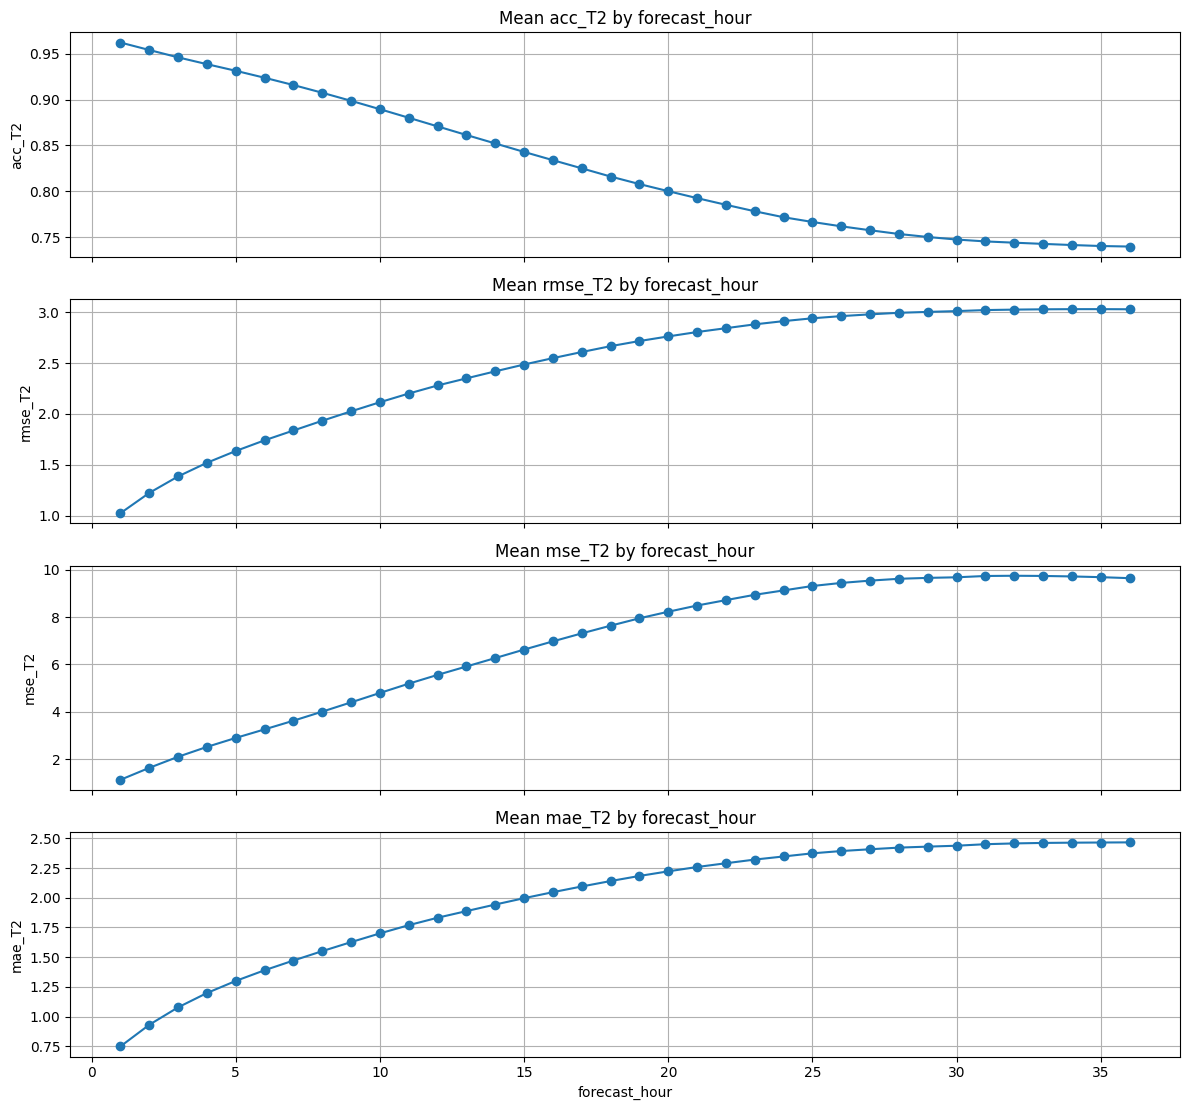

In [4]:
group_col = 'forecast_hour'
plot_metrics = ['T2']  # You can use full metric names (e.g., acc_T2) or variable names (e.g., T2, T_0, RAIN_AMOUNT)

if group_col in df.columns and len(metric_cols) > 0:
    requested_metrics = [m.strip() for m in plot_metrics if isinstance(m, str) and len(m.strip()) > 0]

    selected_metrics = []
    for req in requested_metrics:
        req_lower = req.lower()

        exact_matches = [c for c in metric_cols if c.lower() == req_lower]
        suffix_matches = [c for c in metric_cols if c.lower().endswith(f'_{req_lower}')]

        matches = exact_matches if len(exact_matches) > 0 else suffix_matches
        for col in matches:
            if col not in selected_metrics:
                selected_metrics.append(col)

    if len(selected_metrics) == 0:
        selected_metrics = metric_cols[:min(4, len(metric_cols))]
        print('Requested metrics not found. Falling back to first available metrics:')
    else:
        print('Using requested/resolved metrics found in CSV:')
    print(selected_metrics)

    summary = df.groupby(group_col)[selected_metrics].mean(numeric_only=True).sort_index()
    display(summary.head())

    n_plot = len(selected_metrics)
    fig, axes = plt.subplots(n_plot, 1, figsize=(12, 2.8 * n_plot), sharex=True)
    if n_plot == 1:
        axes = [axes]

    for ax, col in zip(axes, selected_metrics):
        ax.plot(summary.index, summary[col], marker='o')
        ax.set_ylabel(col)
        ax.set_title(f'Mean {col} by {group_col}')

    axes[-1].set_xlabel(group_col)
    plt.tight_layout()
    plt.show()
else:
    print('Could not plot by forecast_hour (missing forecast_hour or metric columns).')

## 2) Rollout Zarr visualization

In [10]:
# Auto-detect rollout format: NetCDF directory vs Zarr store
nc_files = sorted(rollout_path.glob('*.nc')) if rollout_path.is_dir() else []

if len(nc_files) > 0:
    ds = xr.open_mfdataset(
        [str(p) for p in nc_files],
        combine='nested',
        concat_dim='time',
        engine='netcdf4',
    )
    print(f'Opened {len(nc_files)} NetCDF files via open_mfdataset')
else:
    ds = xr.open_zarr(rollout_path)
    print('Opened rollout as Zarr store')

data_vars = list(ds.data_vars)
print(ds)
print('\nVariables:')
print(data_vars)

Opened 36 NetCDF files via open_mfdataset
<xarray.Dataset> Size: 1GB
Dimensions:              (time: 36, level: 17, latitude: 300, longitude: 300)
Coordinates:
  * time                 (time) datetime64[ns] 288B 2019-07-04T00:10:00 ... 2...
  * level                (level) int64 136B 0 1 2 3 4 5 6 ... 11 12 13 14 15 16
  * latitude             (latitude) int64 2kB 0 1 2 3 4 ... 295 296 297 298 299
  * longitude            (longitude) int64 2kB 0 1 2 3 4 ... 295 296 297 298 299
Data variables: (12/16)
    T                    (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(1, 17, 300, 300), meta=np.ndarray>
    QVAPOR               (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(1, 17, 300, 300), meta=np.ndarray>
    U                    (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(1, 17, 300, 300), meta=np.ndarray>
    V                    (time, level, latitude, longitude) float32 220MB dask.array<chunksize=(1, 17

In [11]:
# Interactive controls for variable/time selection (with animation play control)
if HAS_WIDGETS:
    default_var = 'COMPOSITE_REFL_10CM' if 'COMPOSITE_REFL_10CM' in data_vars else data_vars[0]
    max_time_idx = max(int(ds.sizes.get('time', 1)) - 1, 0)
    var_dropdown = widgets.Dropdown(
        options=data_vars,
        value=default_var,
        description='Variable:',
        layout=widgets.Layout(width='450px')
    )
    time_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_time_idx,
        step=1,
        description='Time idx:',
        continuous_update=False,
        layout=widgets.Layout(width='450px')
    )
    play = widgets.Play(
        value=0,
        min=0,
        max=max_time_idx,
        step=1,
        interval=350,
        description='Play'
    )
    widgets.jslink((play, 'value'), (time_slider, 'value'))
    display(widgets.VBox([var_dropdown, widgets.HBox([play, time_slider])]))
    print('Use controls, then run Cells 12 and 13 for updated plots.')
else:
    selected_var = 'COMPOSITE_REFL_10CM' if 'COMPOSITE_REFL_10CM' in data_vars else data_vars[0]
    selected_time_idx = 0
    print('ipywidgets not available. Using selected_var and selected_time_idx fallback values.')

Use controls, then run Cells 12 and 13 for updated plots.


In [12]:
# Load matching ground-truth WoFS case from the original cases directory
truth_root = Path('/work2/zhanxianghua/wofs_preprocess_to_credit/cases')
truth_case_path = truth_root / f"{rollout_path.name}.zarr"
gt_ds = None

if truth_case_path.exists():
    gt_ds = xr.open_zarr(truth_case_path)
    print('Loaded ground-truth case:', truth_case_path)
    print(gt_ds)
else:
    print('Ground-truth case not found:', truth_case_path)

Loaded ground-truth case: /work2/zhanxianghua/wofs_preprocess_to_credit/cases/wofs_20190703_0000_mem01.zarr
<xarray.Dataset> Size: 2GB
Dimensions:                 (time: 37, y: 300, x: 300, level: 17)
Coordinates:
  * time                    (time) datetime64[ns] 296B 2019-07-04 ... 2019-07...
    trajectory_id           (time) float64 296B dask.array<chunksize=(1,), meta=np.ndarray>
  * y                       (y) int64 2kB 0 1 2 3 4 5 ... 295 296 297 298 299
  * x                       (x) int64 2kB 0 1 2 3 4 5 ... 295 296 297 298 299
    latitude                (y, x) float32 360kB dask.array<chunksize=(300, 300), meta=np.ndarray>
    longitude               (y, x) float32 360kB dask.array<chunksize=(300, 300), meta=np.ndarray>
  * level                   (level) int64 136B 0 1 2 3 4 5 ... 11 12 13 14 15 16
Data variables: (12/32)
    COMPOSITE_REFL_10CM     (time, y, x) float32 13MB dask.array<chunksize=(1, 300, 300), meta=np.ndarray>
    GEOPOT                  (time, level, y, x)

Selected variable: T2
Selected time idx: 5
Pred slice dims: ('latitude', 'longitude') shape: (300, 300)
GT   slice dims: ('y', 'x') shape: (300, 300)


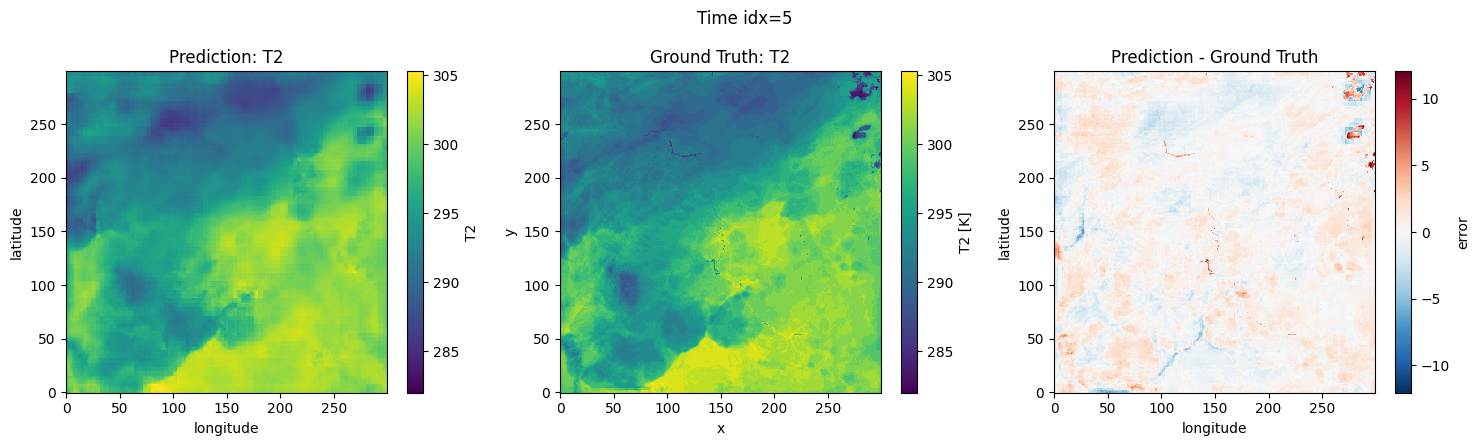

In [18]:
def pick_slice(da: xr.DataArray, time_idx: int = 0):
    indexers = {}
    if 'time' in da.dims:
        indexers['time'] = min(time_idx, int(da.sizes['time']) - 1)
    if 'level' in da.dims:
        indexers['level'] = 0
    elif 'lev' in da.dims:
        indexers['lev'] = 0
    return da.isel(**indexers) if indexers else da

def pick_2d_frame(da: xr.DataArray, time_idx: int = 0):
    frame = pick_slice(da, time_idx=time_idx).squeeze()

    if frame.ndim > 2:
        spatial_pairs = [('y', 'x'), ('south_north', 'west_east'), ('lat', 'lon')]
        selected_pair = None
        for ydim, xdim in spatial_pairs:
            if ydim in frame.dims and xdim in frame.dims:
                selected_pair = (ydim, xdim)
                break

        if selected_pair is not None:
            keep = set(selected_pair)
            indexers = {d: 0 for d in frame.dims if d not in keep}
            frame = frame.isel(**indexers).squeeze()
        else:
            indexers = {d: 0 for d in frame.dims[:-2]}
            frame = frame.isel(**indexers).squeeze()

    return frame

def load_2d_frame(da: xr.DataArray, time_idx: int = 0):
    frame = pick_2d_frame(da, time_idx=time_idx)
    if hasattr(frame, 'load'):
        frame = frame.load()
    return frame

if HAS_WIDGETS and 'var_dropdown' in globals() and 'time_slider' in globals():
    var_to_plot = var_dropdown.value
    time_idx = int(time_slider.value)
else:
    var_to_plot = selected_var if 'selected_var' in globals() else data_vars[0]
    time_idx = int(selected_time_idx) if 'selected_time_idx' in globals() else 0

pred_field = load_2d_frame(ds[var_to_plot], time_idx=time_idx)

gt_field = None
if 'gt_ds' in globals() and gt_ds is not None and var_to_plot in gt_ds.data_vars:
    gt_field = load_2d_frame(gt_ds[var_to_plot], time_idx=time_idx)

print('Selected variable:', var_to_plot)
print('Selected time idx:', time_idx)
print('Pred slice dims:', pred_field.dims, 'shape:', pred_field.shape)
if gt_field is not None:
    print('GT   slice dims:', gt_field.dims, 'shape:', gt_field.shape)

if pred_field.ndim == 2:
    if gt_field is not None and gt_field.ndim == 2 and pred_field.shape == gt_field.shape:
        pred_np = np.asarray(pred_field.values)
        gt_np = np.asarray(gt_field.values)

        err = xr.DataArray(
            pred_np - gt_np,
            dims=pred_field.dims,
            coords={d: pred_field.coords[d] for d in pred_field.dims if d in pred_field.coords},
            name='error',
        )

        pred_min = float(np.nanmin(pred_np))
        gt_min = float(np.nanmin(gt_np))
        pred_max = float(np.nanmax(pred_np))
        gt_max = float(np.nanmax(gt_np))
        vmin = float(np.nanmin([pred_min, gt_min]))
        vmax = float(np.nanmax([pred_max, gt_max]))

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
        pred_field.plot(ax=axes[0], cmap='viridis', vmin=vmin, vmax=vmax, add_colorbar=True)
        axes[0].set_title(f'Prediction: {var_to_plot}')

        gt_field.plot(ax=axes[1], cmap='viridis', vmin=vmin, vmax=vmax, add_colorbar=True)
        axes[1].set_title(f'Ground Truth: {var_to_plot}')

        err.plot(ax=axes[2], cmap='RdBu_r', add_colorbar=True)
        axes[2].set_title('Prediction - Ground Truth')
        plt.suptitle(f'Time idx={time_idx}')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8, 6))
        pred_field.plot(cmap='viridis')
        plt.title(f'{var_to_plot} prediction (time idx={time_idx})')
        plt.tight_layout()
        plt.show()
else:
    print('Field is not 2D after slicing. Inspect manually:')
    display(pred_field)